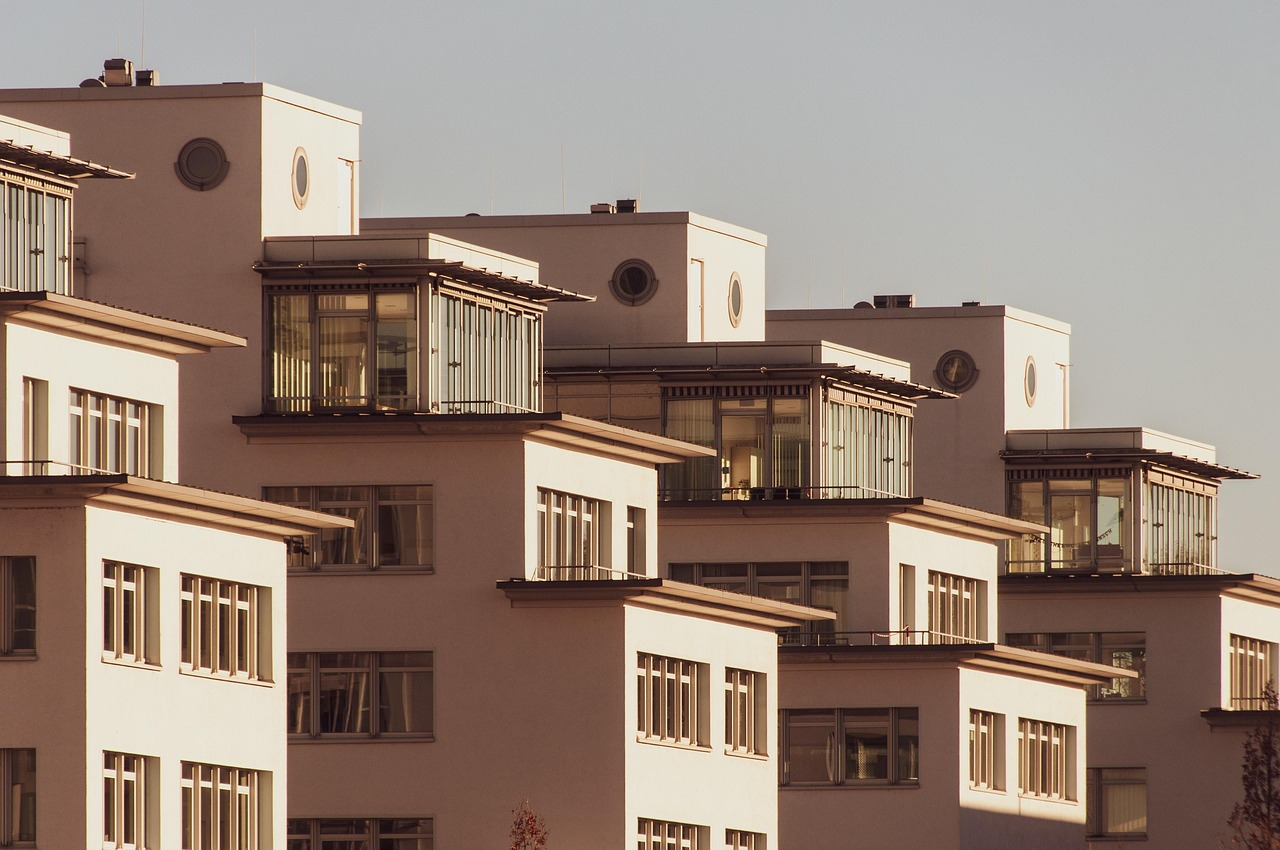

In [7]:
from PIL import Image

img_rgb = Image.open("dataset/house.jpg").convert("RGB")
img_rgb

In [10]:
import numpy as np
img_rgb_np = np.array(img_rgb)
img_rgb_np.shape

(850, 1280, 3)

In [11]:
R, G, B = img_rgb_np[:, :, 0], img_rgb_np[:, :, 1], img_rgb_np[:, :, 2]

In [13]:
Y  = 0.299*R + 0.587*G + 0.114*B
Cr = 0.5*R - 0.4187*G - 0.0813*B
Cb = -0.1687*R - 0.3313*G + 0.5*B

In [23]:
Y_img = Image.fromarray(Y.astype(np.uint8), mode="L")
Cr_img = Image.fromarray(Cr.astype(np.uint8), mode="L")
Cb_img = Image.fromarray(Cb.astype(np.uint8), mode="L")

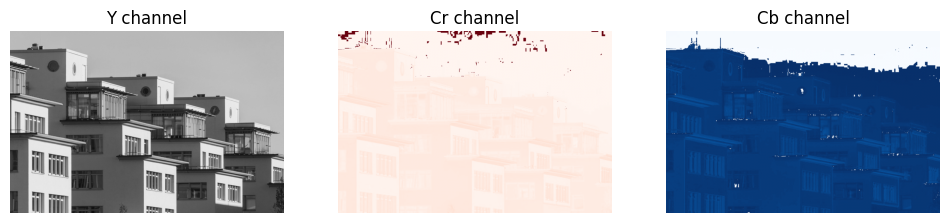

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(Y_img, cmap="gray")
plt.title("Y channel")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(Cr_img, cmap="Reds")
plt.title("Cr channel")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(Cb_img, cmap="Blues")
plt.title("Cb channel")
plt.axis("off")
plt.show()

In [35]:
import torch 

Y_tensor = torch.tensor(Y, dtype=torch.float32)
spec = torch.fft.fft2(Y_tensor, norm='ortho')

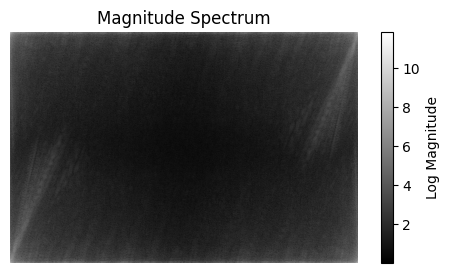

In [67]:
magnitude_spectrum = torch.abs(spec) + 1e-8

plt.figure(figsize=(6, 3))
plt.imshow(torch.log1p(magnitude_spectrum).numpy(), cmap='gray')
plt.title("Magnitude Spectrum")
plt.axis("off")
plt.colorbar(label="Log Magnitude")
plt.show()

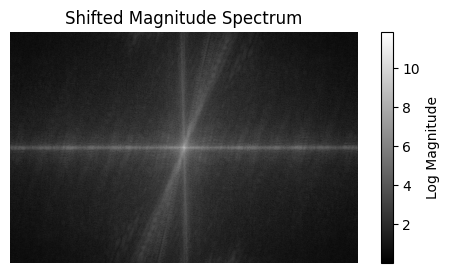

In [66]:
spec_shifted = torch.fft.fftshift(spec)
plt.figure(figsize=(6,3))
plt.imshow(torch.log1p(torch.abs(spec_shifted) + 1e-8).numpy(), cmap="gray")
plt.title("Shifted Magnitude Spectrum")
plt.axis("off")
plt.colorbar(label="Log Magnitude")
plt.show()

In [137]:
spec_shifted.shape

torch.Size([850, 1280])

In [125]:
H = 850
W = 1280
mask = torch.ones(H, W, dtype=torch.float32)
mask


tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

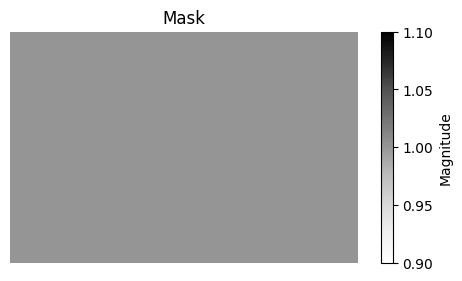

In [127]:
plt.figure(figsize=(6,3))
plt.imshow(mask, cmap="Grays")
plt.title("Mask")
plt.axis("off")
plt.colorbar(label="Magnitude")
plt.show()

In [131]:
center_h, center_w = H//2, W//2
y = torch.arange(H).reshape(-1, 1)
x = torch.arange(W).reshape(1, -1)
distance = torch.sqrt((y - center_h)**2 + (x - center_w)**2) 

mask[distance <= 40] = 0


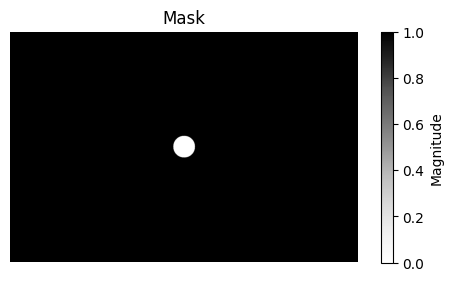

In [132]:
plt.figure(figsize=(6,3))
plt.imshow(mask, cmap="Grays")
plt.title("Mask")
plt.axis("off")
plt.colorbar(label="Magnitude")
plt.show()

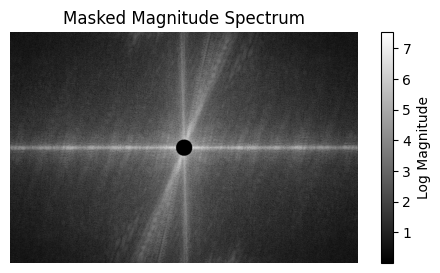

In [117]:
masked_spec = spec_shifted * mask
plt.figure(figsize=(6,3))
plt.imshow(torch.log1p(torch.abs(masked_spec) + 1e-8).numpy(), cmap="gray")
plt.title("Masked Magnitude Spectrum")
plt.axis("off")
plt.colorbar(label="Log Magnitude")
plt.show()

(np.float64(-0.5), np.float64(1279.5), np.float64(849.5), np.float64(-0.5))

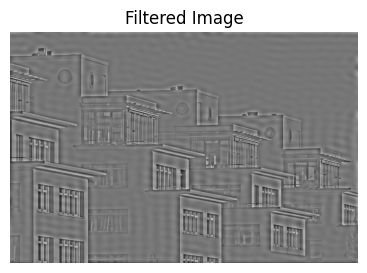

In [118]:
Yhf = torch.fft.ifft2(torch.fft.fftshift(masked_spec), norm='ortho').real
plt.figure(figsize=(6,3))
plt.imshow(Yhf.numpy(), cmap="gray")
plt.title("Filtered Image")
plt.axis("off")

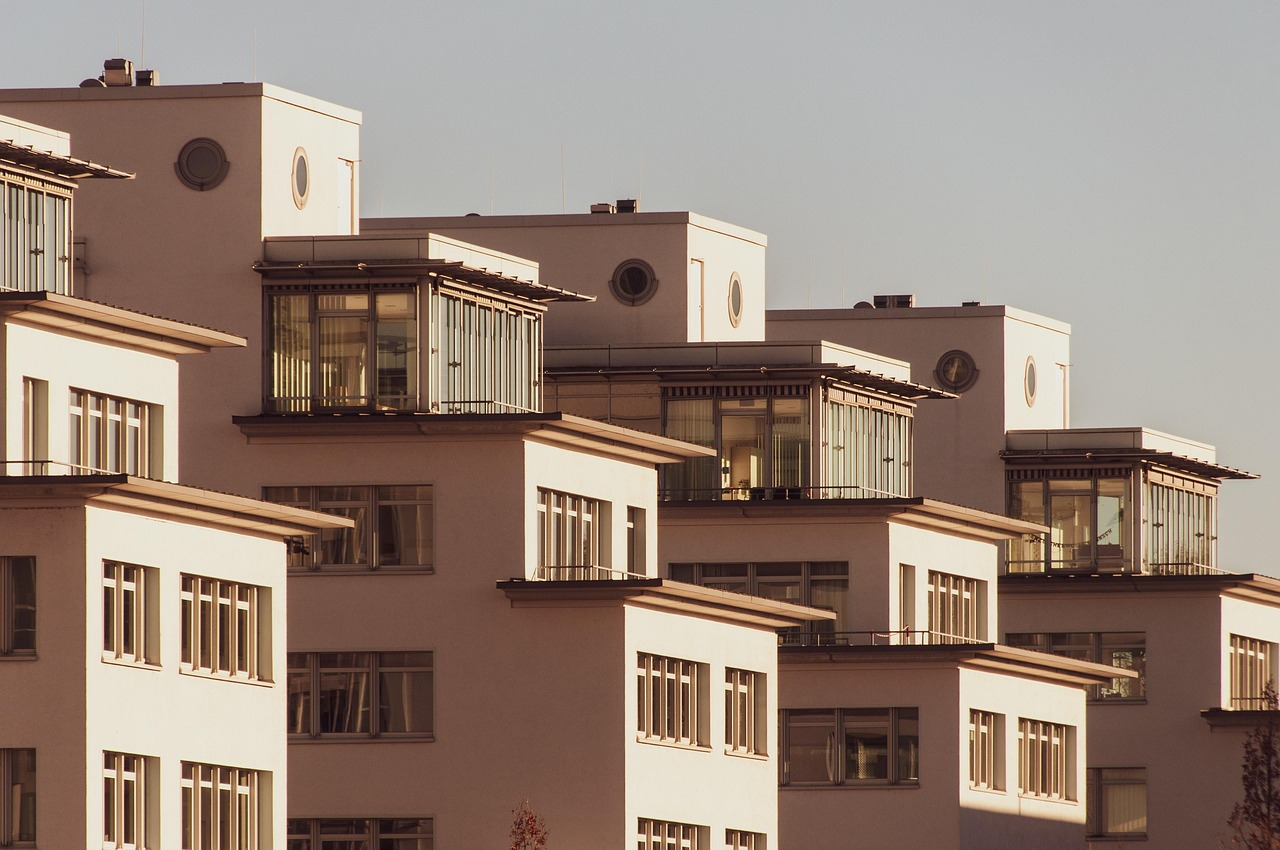

In [138]:
img

AttributeError: module 'matplotlib.pyplot' has no attribute 'text2D'

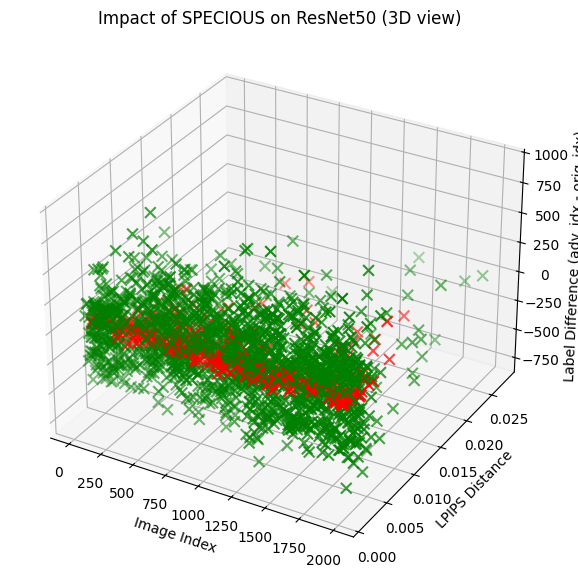

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load data from CSV
df = pd.read_csv("resnet50_fooling_data/results.csv")

# Compute average fooling rate
avg_fool_rate = df['fooled'].mean() * 100  # in percent

# Calculate label difference (numeric index difference)
df['label_diff'] = df['adv_idx'] - df['orig_idx']

# Create 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Map fooling to colors
colors = df['fooled'].map({1: 'green', 0: 'red'})

# Plot using 'x' marker
ax.scatter(df['index'], df['lpips'], df['label_diff'], c=colors, marker='x', s=60)

# Labels
ax.set_xlabel('Image Index')
ax.set_ylabel('LPIPS Distance')
ax.set_zlabel('Label Difference (adv_idx - orig_idx)')
ax.set_title('Impact of SPECIOUS on ResNet50 (3D view)')

# Annotate average fooling rate
plt.text2D(0.05, 0.95, f"Avg Fooling Rate: {avg_fool_rate:.1f}%", transform=ax.transAxes, fontsize=12, fontweight='bold')

# Legend
import matplotlib.patches as mpatches
fooled_patch = mpatches.Patch(color='green', label='Fooled')
notfooled_patch = mpatches.Patch(color='red', label='Not Fooled')
ax.legend(handles=[fooled_patch, notfooled_patch], loc='upper left')

plt.tight_layout()
plt.show()


Average LPIPS: 0.0047
Average Fooling Rate: 80.25%
Average Confidence Drop: 0.1240


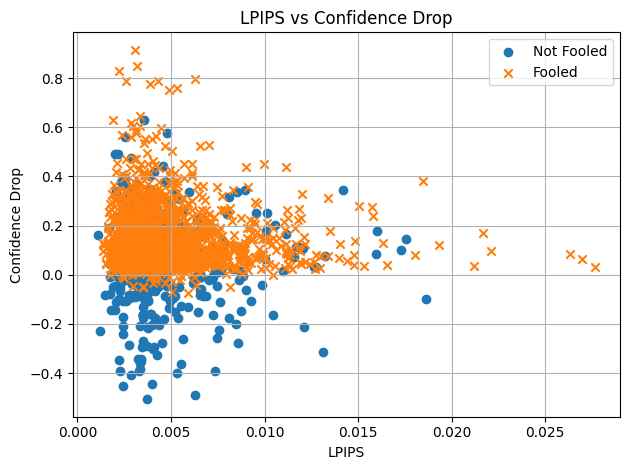

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('resnet50_fooling_data/results.csv')

# Compute summary statistics
avg_lpips = df['lpips'].mean()
fooling_rate = df['fooled'].mean() * 100
avg_conf_drop = df['confidence_drop'].mean()

print(f"Average LPIPS: {avg_lpips:.4f}")
print(f"Average Fooling Rate: {fooling_rate:.2f}%")
print(f"Average Confidence Drop: {avg_conf_drop:.4f}")

# Scatter plot: LPIPS vs Confidence Drop
plt.figure()
plt.scatter(df[df['fooled'] == 0]['lpips'], 
            df[df['fooled'] == 0]['confidence_drop'], 
            marker='o', label='Not Fooled')
plt.scatter(df[df['fooled'] == 1]['lpips'], 
            df[df['fooled'] == 1]['confidence_drop'], 
            marker='x', label='Fooled')

plt.title('LPIPS vs Confidence Drop')
plt.xlabel('LPIPS')
plt.ylabel('Confidence Drop')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save the plot
plt.savefig('lpips_confidence_drop_scatter.png')
plt.show()


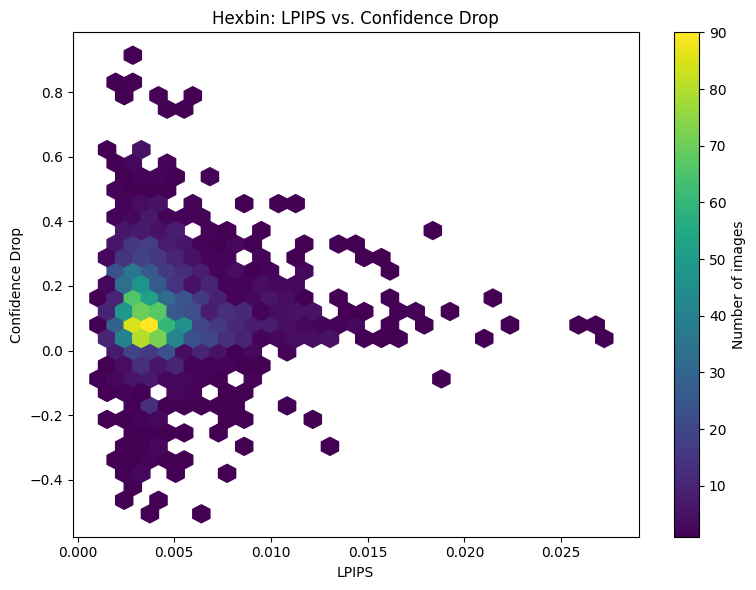

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your CSV
df = pd.read_csv('resnet50_fooling_data/results.csv')

plt.figure(figsize=(8, 6))
hb = plt.hexbin(df['lpips'], df['confidence_drop'], 
                gridsize=30,               # adjust for resolution
                cmap='viridis',            # default colormap
                mincnt=1)                  # hide empty bins

plt.colorbar(hb, label='Number of images')
plt.xlabel('LPIPS')
plt.ylabel('Confidence Drop')
plt.title('Hexbin: LPIPS vs. Confidence Drop')
plt.tight_layout()
plt.show()


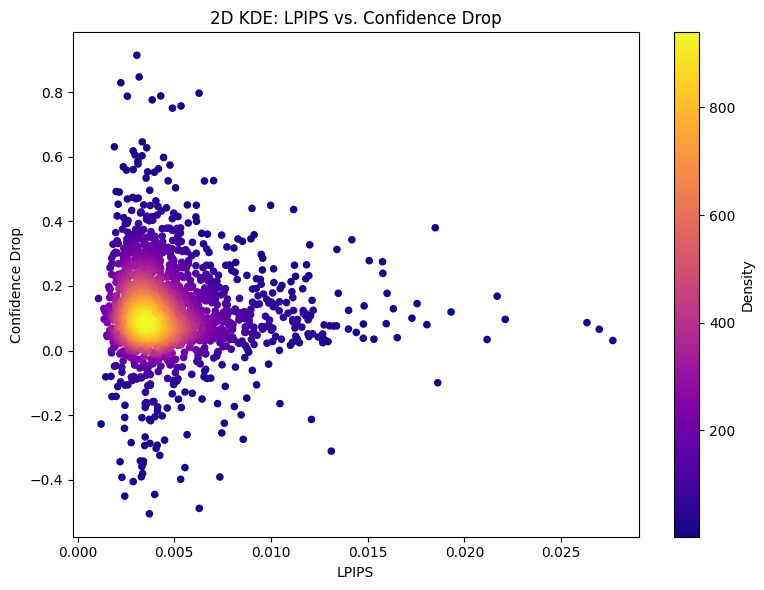

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

df = pd.read_csv('resnet50_fooling_data/results.csv')
x, y = df['lpips'], df['confidence_drop']
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=z, s=20, cmap='plasma')
plt.xlabel('LPIPS')
plt.ylabel('Confidence Drop')
plt.title('2D KDE: LPIPS vs. Confidence Drop')
plt.colorbar(label='Density')
plt.tight_layout()
plt.show()


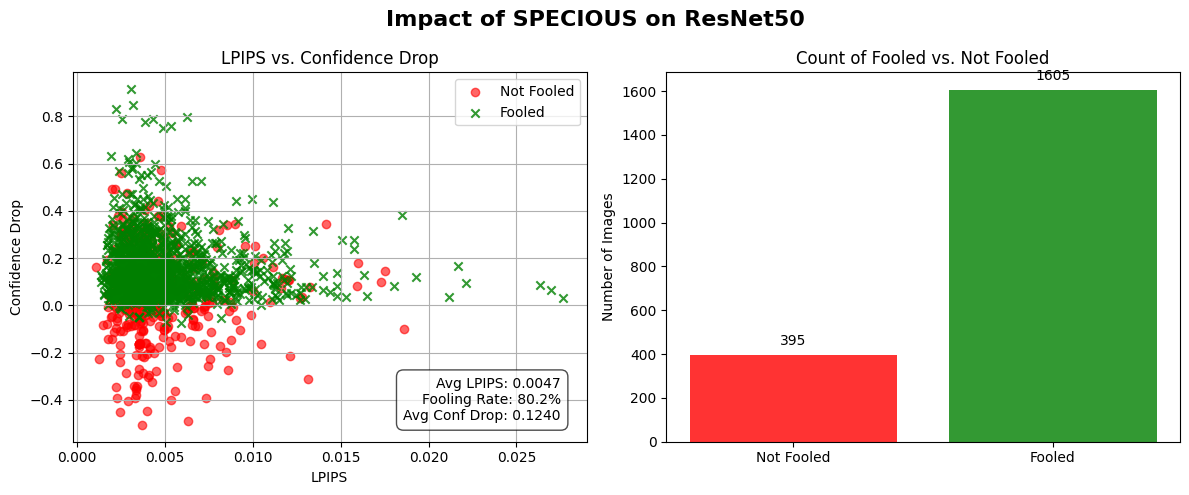

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('resnet50_fooling_data/results.csv')

# Compute summary statistics
avg_lpips      = df['lpips'].mean()
fooling_rate   = df['fooled'].mean() * 100
avg_conf_drop  = df['confidence_drop'].mean()

# Prepare figure with two subplots, side by side
fig, (ax_scatter, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Impact of SPECIOUS on ResNet50", fontsize=16, fontweight='bold')

# ─── Scatter Plot ───────────────────────────────────────────────────────────────
# Plot fooled vs. not fooled
ax_scatter.scatter(df[df['fooled'] == 0]['lpips'],
                   df[df['fooled'] == 0]['confidence_drop'],
                   marker='o', label='Not Fooled', alpha=0.6, color='red')
ax_scatter.scatter(df[df['fooled'] == 1]['lpips'],
                   df[df['fooled'] == 1]['confidence_drop'],
                   marker='x', label='Fooled', alpha=0.8, color='green')

# Annotate metrics in the bottom-right corner of the scatter plot
metrics_text = (
    f"Avg LPIPS: {avg_lpips:.4f}\n"
    f"Fooling Rate: {fooling_rate:.1f}%\n"
    f"Avg Conf Drop: {avg_conf_drop:.4f}"
)
ax_scatter.text(
    0.95, 0.05, metrics_text,
    transform=ax_scatter.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7)
)

ax_scatter.set_title('LPIPS vs. Confidence Drop')
ax_scatter.set_xlabel('LPIPS')
ax_scatter.set_ylabel('Confidence Drop')
ax_scatter.legend()
ax_scatter.grid(True)

# ─── Bar Plot ─────────────────────────────────────────────────────────────────
counts = df['fooled'].value_counts().sort_index()
labels = ['Not Fooled', 'Fooled']
values = [counts.get(0, 0), counts.get(1, 0)]
bar_colors = ['red', 'green']  # Match colors with scatter plot

ax_bar.bar(labels, values, alpha=0.8, color=bar_colors)
ax_bar.set_title('Count of Fooled vs. Not Fooled')
ax_bar.set_ylabel('Number of Images')
for i, v in enumerate(values):
    ax_bar.text(i, v + max(values)*0.02, str(v), ha='center', va='bottom')

# ─── Finalize & Save ──────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('lpips_confidence_and_fooling_summary.png', dpi=300)
plt.show()


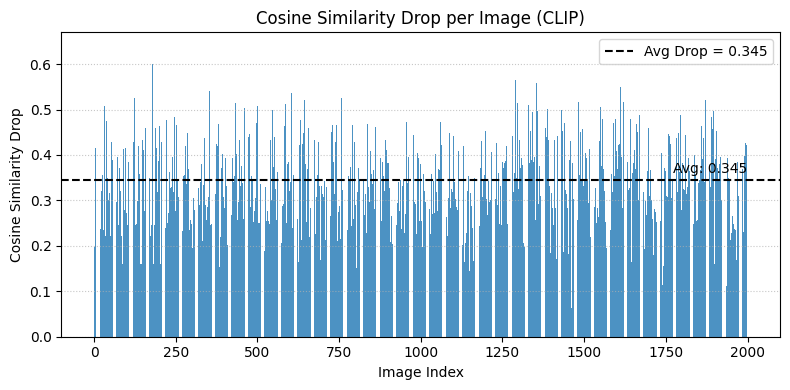

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────────────────────
# 1. Load the CSV data
# ────────────────────────────────────────────────────────────────────────────────
# Replace with your actual path if different
csv_path = 'Post Data/plot data/clip_fooling_data/results.csv'
df = pd.read_csv(csv_path)

# ────────────────────────────────────────────────────────────────────────────────
# 2. Compute summary statistic
# ────────────────────────────────────────────────────────────────────────────────
# Average cosine-similarity drop across all images
avg_drop = df['clip_drop'].mean()

# ────────────────────────────────────────────────────────────────────────────────
# 3. Plotting
# ────────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))

# Bar plot of drop per image index
plt.bar(df['index'], df['clip_drop'], alpha=0.8)

# Horizontal line for average drop
plt.axhline(avg_drop, color='black', linestyle='--', 
            label=f'Avg Drop = {avg_drop:.3f}')

# Annotate the average on the plot
plt.text(
    df['index'].max(), 
    avg_drop + 0.01, 
    f'Avg: {avg_drop:.3f}', 
    ha='right', 
    va='bottom'
)

# Labels, title, grid, legend
plt.xlabel('Image Index')
plt.ylabel('Cosine Similarity Drop')
plt.title('Cosine Similarity Drop per Image (CLIP)')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


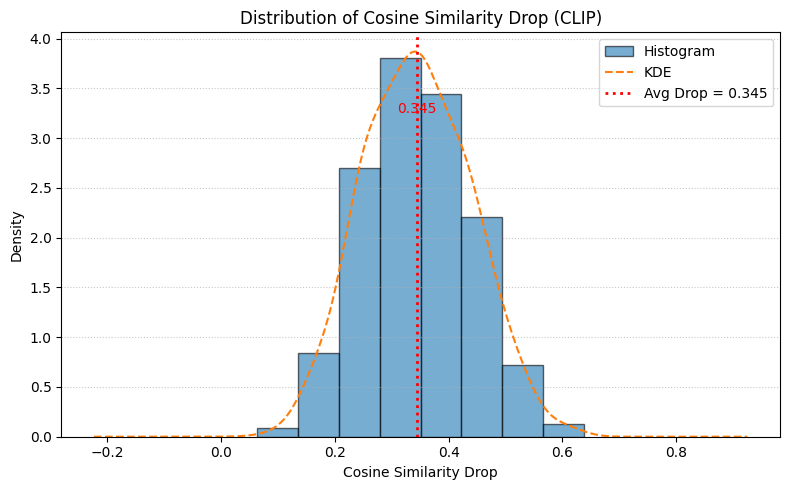

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('Post Data/plot data/clip_fooling_data/results.csv')

# 2. Extract the drop values
drops = df['clip_drop']

# 3. Plot histogram + KDE
plt.figure(figsize=(8, 5))

# Histogram
plt.hist(drops, bins=8, alpha=0.6, edgecolor='black', density=True, label='Histogram')

# KDE (smoothed density)
drops.plot(kind='kde', linestyle='--', label='KDE', bw_method=0.3)

# Annotations
avg_drop = drops.mean()
plt.axvline(avg_drop, color='red', linestyle=':', linewidth=2, label=f'Avg Drop = {avg_drop:.3f}')
plt.text(avg_drop, plt.ylim()[1]*0.8, f'{avg_drop:.3f}', color='red', ha='center')

# Labels & legend
plt.title('Distribution of Cosine Similarity Drop (CLIP)')
plt.xlabel('Cosine Similarity Drop')
plt.ylabel('Density')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('clip_cosine_similarity_drop_distribution.png', dpi=300)
plt.show()




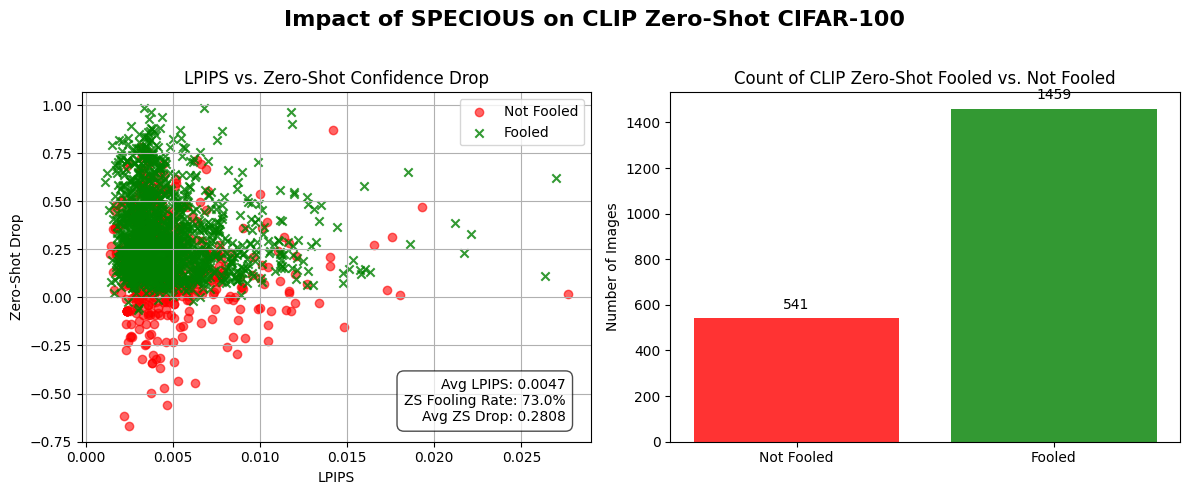

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CLIP zero-shot data
df = pd.read_csv('clip_fooling_data/results.csv')

# Compute summary statistics
avg_lpips     = df['lpips'].mean()
zs_fooling_rate = df['zs_fooled'].mean() * 100
avg_zs_drop   = df['zs_confidence_drop'].mean()

# Prepare figure with two subplots, side by side
fig, (ax_scatter, ax_bar) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Impact of SPECIOUS on CLIP Zero-Shot CIFAR-100", fontsize=16, fontweight='bold')

# ─── Scatter Plot ───────────────────────────────────────────────────────────────
# Plot fooled vs. not fooled
ax_scatter.scatter(
    df[df['zs_fooled'] == 0]['lpips'],
    df[df['zs_fooled'] == 0]['zs_confidence_drop'],
    marker='o', label='Not Fooled', alpha=0.6, color='red'
)
ax_scatter.scatter(
    df[df['zs_fooled'] == 1]['lpips'],
    df[df['zs_fooled'] == 1]['zs_confidence_drop'],
    marker='x', label='Fooled', alpha=0.8, color='green'
)

# Annotate metrics in the bottom-right corner
metrics_text = (
    f"Avg LPIPS: {avg_lpips:.4f}\n"
    f"ZS Fooling Rate: {zs_fooling_rate:.1f}%\n"
    f"Avg ZS Drop: {avg_zs_drop:.4f}"
)
ax_scatter.text(
    0.95, 0.05, metrics_text,
    transform=ax_scatter.transAxes,
    fontsize=10,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7)
)

ax_scatter.set_title('LPIPS vs. Zero-Shot Confidence Drop')
ax_scatter.set_xlabel('LPIPS')
ax_scatter.set_ylabel('Zero-Shot Drop')
ax_scatter.legend()
ax_scatter.grid(True)

# ─── Bar Plot ─────────────────────────────────────────────────────────────────
counts = df['zs_fooled'].value_counts().sort_index()
labels = ['Not Fooled', 'Fooled']
values = [counts.get(0, 0), counts.get(1, 0)]
bar_colors = ['red', 'green']  # match the scatter

ax_bar.bar(labels, values, alpha=0.8, color=bar_colors)
ax_bar.set_title('Count of CLIP Zero-Shot Fooled vs. Not Fooled')
ax_bar.set_ylabel('Number of Images')
for i, v in enumerate(values):
    ax_bar.text(i, v + max(values)*0.02, str(v), ha='center', va='bottom')

# ─── Finalize & Save ──────────────────────────────────────────────────────────
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.savefig('lpips_zeroshot_clip_summary.png', dpi=300)
plt.show()


Saved smoothed plot to training_smoothed.png


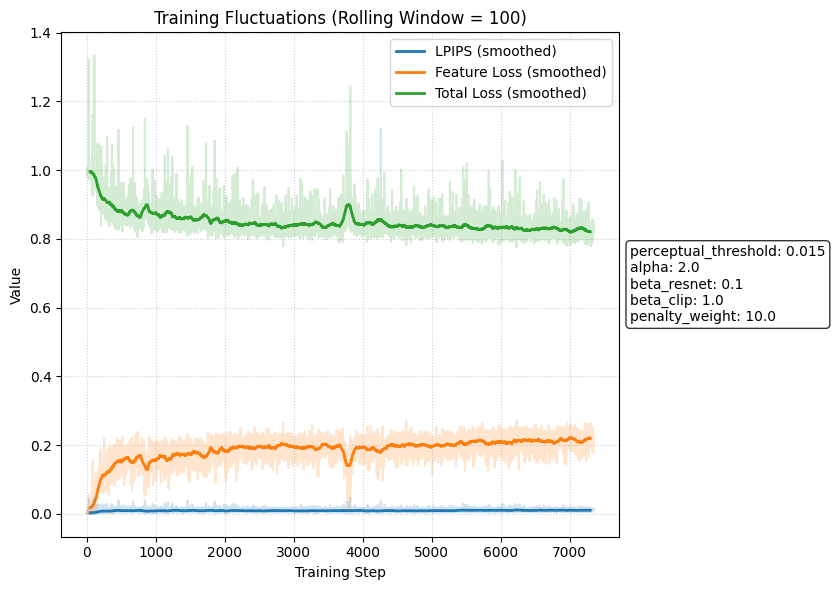

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
csv_path = 'Post Data/final low lpips train/model_history/training_history1.csv'
df = pd.read_csv(csv_path)

# 2. Compute a rolling mean with window=100 (adjust window size to taste)
window_size = 100
df_smooth = df[['lpips', 'feature_loss', 'total_loss']].rolling(window=window_size, center=True).mean()

# 3. Use the DataFrame index as a continuous step axis (or build a global_step if you prefer)
x = df.index

# 4. Plot raw vs. smoothed
fig, ax = plt.subplots(figsize=(10, 6))

# Plot smoothed lines
ax.plot(x, df_smooth['lpips'],        label='LPIPS (smoothed)',        linewidth=2)


# (Optional) Overlay a faint raw line for context
alpha_raw = 0.2
ax.plot(x, df['lpips'],        color='C0', alpha=alpha_raw)


ax.set_xlabel('Training Step')
ax.set_ylabel('Value')
ax.set_title(f'Training Fluctuations (Rolling Window = {window_size})')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

# 5. Hyperparameter box
hyperparams = {
    "perceptual_threshold": 0.015,
    "alpha":                2.0,
    "beta_resnet":          0.1,
    "beta_clip":            1.0,
    "penalty_weight":       10.0
}
txt = '\n'.join(f"{k}: {v}" for k, v in hyperparams.items())
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
ax.text(1.02, 0.5, txt, transform=ax.transAxes, fontsize=10,
        verticalalignment='center', bbox=props)

# 6. Save and show
plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space for box
output_file = 'training_smoothed.png'
plt.savefig(output_file, dpi=300)
print(f"Saved smoothed plot to {output_file}")
plt.show()


### 3.4 SpeciousLoss: Joint Perceptual–Feature Objective

Our **SpeciousLoss** is designed to drive the generator to produce perturbations that are **imperceptible to humans** yet **maximally disruptive** to multiple surrogate encoders simultaneously. It combines three terms:

1. **Perceptual Similarity (LPIPS)**
   We measure human‐perceived similarity using the Learned Perceptual Image Patch Similarity (LPIPS) metric, which compares deep feature activations from a pretrained network (e.g., AlexNet) and has been shown to correlate strongly with human judgments ([GitHub][1]). Formally, given an original image $x$ and perturbed image $\tilde x$,

   $$
     d_{\mathrm{LPIPS}}(x,\tilde x)\;=\;\mathrm{LPIPS}\bigl(x,\tilde x\bigr),
   $$

   where a score near 0 indicates near‑perfect perceptual similarity, and values up to 1 indicate greater dissimilarity ([Lightning AI][2]). By including LPIPS in our loss, we ensure generated perturbations remain below human detection thresholds.

2. **Feature Distortion (ResNet‑50 & CLIP)**
   To disrupt model inference, we penalize the **squared‑error** between feature embeddings of $x$ and $\tilde x$ across two surrogate encoders:

   * **ResNet‑50** pooled features $\phi_r(\cdot)\in\mathbb{R}^{2048}$ from the final average‐pool layer of a pretrained ResNet‑50 ([arXiv][3]).
   * **CLIP ViT‑B/32** vision embeddings $\phi_c(\cdot)\in\mathbb{R}^{512}$ from the CLIP model’s vision transformer ([arXiv][4]).

   We define the combined feature distortion as

   $$
     L_{\mathrm{feat}}
     = \beta_r\,\bigl\|\phi_r(x)-\phi_r(\tilde x)\bigr\|^2
       \;+\;\beta_c\,\bigl\|\phi_c(x)-\phi_c(\tilde x)\bigr\|^2.
   $$

   By selecting appropriate weights $\beta_r,\beta_c$, we tune the relative emphasis on each surrogate.

3. **Strict Positivity & Imperceptibility Penalty**
   To guarantee a **positive‐valued** loss surface—which stabilizes optimization and avoids negative plateaus—we wrap the perceptual and feature terms in an exponential:

   $$
     L_{\exp}
     = \exp\bigl(\,\alpha\,d_{\mathrm{LPIPS}}(x,\tilde x)\;-\;L_{\mathrm{feat}}\bigr).
   $$

   Finally, to enforce a hard upper bound on perceptual distortion, we add a hinge‐penalty whenever LPIPS exceeds a threshold $\tau$:

   $$
     L_{\mathrm{pen}} = \lambda \,\max\bigl(0,\;d_{\mathrm{LPIPS}}(x,\tilde x)\;-\;\tau\bigr).
   $$

   The full SpeciousLoss is thus

   $$
     \boxed{
       \mathcal{L}_{\mathrm{Specious}}
       = L_{\exp} + L_{\mathrm{pen}}.
     }
   $$

#### Hyperparameter Settings

In our experiments on 224×224 images over 7 epochs, we found the following values effective:

* $\alpha=2.0$: scales LPIPS to balance perceptual fidelity.
* $\beta_r=0.0,\;\beta_c=1.0$: we emphasize disrupting CLIP over ResNet, as CLIP features are more aligned with text‐conditioned generators .
* $\tau=0.015$: keeps LPIPS below 0.02, a level generally imperceptible to human observers ([transferlab.ai][5]).
* $\lambda=10.0$: a strong penalty to discourage any breach of $\tau$.

These settings yielded **avg. LPIPS** ≈ 0.012 and **CLIP feature shift** > 0.5 in our validation set, with negligible visual artifacts.

---

Shall I continue with **3.5 Training Procedure**?

[1]: https://github.com/richzhang/PerceptualSimilarity?utm_source=chatgpt.com "richzhang/PerceptualSimilarity: LPIPS metric. pip install lpips - GitHub"
[2]: https://lightning.ai/docs/torchmetrics/stable/image/learned_perceptual_image_patch_similarity.html?utm_source=chatgpt.com "Learned Perceptual Image Patch Similarity (LPIPS) - Lightning AI"
[3]: https://arxiv.org/abs/1512.03385?utm_source=chatgpt.com "Deep Residual Learning for Image Recognition"
[4]: https://arxiv.org/pdf/2103.00020?utm_source=chatgpt.com "[PDF] Learning Transferable Visual Models From Natural Language ..."
[5]: https://transferlab.ai/blog/perceptual-metrics/?utm_source=chatgpt.com "Can perceptual similarity metrics be used to compare adversarial ..."
